# Fenwick Tree Demo

## Fenwick Tree Drawing Method From ChatGPT

In [121]:
import matplotlib.pyplot as plt

def draw_fenwick_tree_right(bit, one_indexed=True,
                            highlight_indices=None,
                            R_index=None,
                            filename=None):
    """
    Draw a Fenwick tree with edges going to the right (i -> i + lowbit(i)),
    ending at a node labelled 'R', similar to the provided diagram.

    Parameters
    ----------
    bit : list[int]
        Internal Fenwick array.
        If one_indexed=True  -> bit[0..m], with bit[0] usually unused.
        If one_indexed=False -> bit[0..m-1], we'll prepend a dummy 0.
    one_indexed : bool
        Whether `bit` already has a dummy element at index 0.
    highlight_indices : iterable[int] or None
        Indices to highlight (by index label). You can also pass R_index here
        if you want the R node highlighted.
    R_index : int or None
        Index shown under the rightmost 'R' node. If None, defaults to m+1.
        (m is the maximum Fenwick index.)
    filename : str or None
        If given, save the figure to this path as a PNG.
    """
    if not bit:
        raise ValueError("bit must be a non-empty sequence")

    # Normalize array to 1-based internal indexing
    if one_indexed:
        arr = list(bit)
        m = len(arr) - 1
    else:
        arr = [0] + list(bit)
        m = len(arr) - 1

    if R_index is None:
        R_index = m + 1

    highlight_set = set(highlight_indices or [])

    # ---------- compute depth from the RIGHT (update direction) ----------
    # depth_right[i] = how many hops i can make via j += lowbit(j)
    # before leaving [1..m]. Nodes closer to the right (8, 10, ...) have
    # smaller depth.
    depth = {}
    for i in range(1, m + 1):
        d = 0
        j = i
        while j <= m:
            j += j & -j
            d += 1
        depth[i] = d

    # R is the root/sink at depth 0
    depth_R = 0

    # ---------- layout parameters ----------
    h_spacing = 1.5   # horizontal distance between indices
    v_spacing = 1.2   # vertical distance between levels
    radius    = 0.35

    xs = {i: i * h_spacing for i in range(1, m + 1)}
    ys = {i: -depth[i] * v_spacing for i in range(1, m + 1)}

    x_R = (m + 1) * h_spacing
    y_R = -depth_R * v_spacing

    max_depth = max(depth.values()) if depth else 0

    fig_width  = max(8, (m + 1) * 1.1)
    fig_height = 3 + max_depth * 0.6

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    # Background like the screenshots
    bg = "#f2f2f2"
    fig.patch.set_facecolor(bg)
    ax.set_facecolor(bg)

    edge_color = "#333333"

    # ---------- draw edges i -> i + lowbit(i) (or to R if beyond m) ----------
    for i in range(1, m + 1):
        j = i + (i & -i)
        x1, y1 = xs[i], ys[i]
        if j <= m:
            x2, y2 = xs[j], ys[j]
        else:
            x2, y2 = x_R, y_R
        ax.plot(
            [x1, x2], [y1, y2],
            color=edge_color,
            linewidth=3,
            solid_capstyle="round",
            zorder=1,
        )

    # ---------- draw Fenwick nodes 1..m ----------
    for i in range(1, m + 1):
        x, y = xs[i], ys[i]

        if i in highlight_set:
            circle_edge = "#b00000"
            circle_face = "#ffcccc"
            value_color = "white"
        else:
            circle_edge = edge_color
            circle_face = "white"
            value_color = "black"

        circle = plt.Circle(
            (x, y),
            radius,
            edgecolor=circle_edge,
            facecolor=circle_face,
            linewidth=3,
            zorder=2,
        )
        ax.add_patch(circle)

        # value inside the circle
        val = arr[i]
        ax.text(
            x, y,
            f"{val}",
            ha="center",
            va="center",
            fontsize=14,
            color=value_color,
            zorder=3,
        )

        # index under the circle: show m=... for the last Fenwick index
        idx_label = f"m={i}" if i == m else str(i)
        ax.text(
            x, y - radius - 0.25,
            idx_label,
            ha="center",
            va="top",
            fontsize=12,
            color="red",
            zorder=3,
        )

    # ---------- draw the R node ----------
    if R_index in highlight_set:
        circle_edge = "#b00000"
        circle_face = "#ffcccc"
        value_color = "white"
    else:
        circle_edge = edge_color
        circle_face = "white"
        value_color = "black"

    circle_R = plt.Circle(
        (x_R, y_R),
        radius,
        edgecolor=circle_edge,
        facecolor=circle_face,
        linewidth=3,
        zorder=2,
    )
    ax.add_patch(circle_R)

    ax.text(
        x_R, y_R,
        "R",
        ha="center",
        va="center",
        fontsize=14,
        color=value_color,
        zorder=3,
    )

    ax.text(
        x_R, y_R - radius - 0.25,
        str(R_index),
        ha="center",
        va="top",
        fontsize=12,
        color="red",
        zorder=3,
    )

    ax.set_xlim(h_spacing * 0.5, (m + 1.5) * h_spacing)
    ax.set_ylim(-max_depth * v_spacing - 2, radius + 2)
    ax.axis("off")

    if filename:
        fig.savefig(filename, dpi=150, bbox_inches="tight", facecolor=bg)

    plt.show()


In [110]:
import matplotlib.pyplot as plt

def draw_fenwick_tree(bit, one_indexed=True, highlight_indices=None, filename=None):
    """
    Draw a Fenwick tree in the same style as the provided diagram.

    Parameters
    ----------
    bit : list[int]
        Internal Fenwick array.
        If one_indexed=True  -> bit[0..m], with bit[0] for index 0 (usually 0).
        If one_indexed=False -> bit[0..m-1], index 0 node will be created as 0.
    one_indexed : bool
        Whether `bit` already has a dummy element at index 0.
    highlight_indices : iterable[int] or None
        Indices (0..m) whose nodes should be highlighted in red.
        These are the same indices that are drawn under the circles.
    filename : str or None
        If given, save the figure to this path as a PNG.
    """
    if not bit:
        raise ValueError("bit must be a non-empty sequence")

    if one_indexed:
        arr = list(bit)
        m = len(arr) - 1        # highest index
    else:
        # create an index-0 node (value 0) in front
        arr = [0] + list(bit)
        m = len(arr) - 1

    # normalize highlight set
    highlight_set = set(highlight_indices or [])

    # ---------- compute depth (how far below the root each node is) ----------
    depth = {0: 0}
    for i in range(1, m + 1):
        d = 0
        j = i
        while j > 0:
            j -= j & -j
            d += 1
        depth[i] = d

    # ---------- layout parameters ----------
    h_spacing = 1.5   # horizontal distance between indices
    v_spacing = 1.2   # vertical distance between levels
    radius    = 0.35

    xs = {i: i * h_spacing for i in range(0, m + 1)}
    ys = {i: -depth[i] * v_spacing for i in range(0, m + 1)}

    max_depth = max(depth.values()) if depth else 0

    fig_width  = max(8, m * 1.1)
    fig_height = 3 + max_depth * 0.6

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    # background like the screenshot
    bg = "#f2f2f2"
    fig.patch.set_facecolor(bg)
    ax.set_facecolor(bg)

    edge_color = "#333333"

    # ---------- draw edges (parent -> child) ----------
    for i in range(1, m + 1):
        parent = i - (i & -i)   # Fenwick parent
        x1, y1 = xs[parent], ys[parent]
        x2, y2 = xs[i], ys[i]
        ax.plot(
            [x1, x2], [y1, y2],
            color=edge_color,
            linewidth=3,
            solid_capstyle="round",
            zorder=1,
        )

    # ---------- draw nodes ----------
    for i in range(0, m + 1):
        x, y = xs[i], ys[i]

        if i in highlight_set:
            circle_edge = "#b00000"
            circle_face = "#ffcccc"
            value_color = "white"
        else:
            circle_edge = edge_color
            circle_face = "white"
            value_color = "black"

        circle = plt.Circle(
            (x, y),
            radius,
            edgecolor=circle_edge,
            facecolor=circle_face,
            linewidth=3,
            zorder=2,
        )
        ax.add_patch(circle)

        # value inside the circle
        val = arr[i] if i < len(arr) else 0
        ax.text(
            x, y,
            f"{val}",
            ha="center",
            va="center",
            fontsize=14,
            color=value_color,
            zorder=3,
        )

        # index below the circle (red); last one as m=...
        idx_label = f"m={i}" if i == m else str(i)
        ax.text(
            x, y - radius - 0.25,
            idx_label,
            ha="center",
            va="top",
            fontsize=12,
            color="red",
            zorder=3,
        )

    ax.set_xlim(-h_spacing, (m + 1) * h_spacing)
    ax.set_ylim(min(ys.values()) - 2, radius + 2)
    ax.axis("off")

    if filename:
        fig.savefig(filename, dpi=150, bbox_inches="tight", facecolor=bg)

    plt.show()



In [103]:
import matplotlib.pyplot as plt

def draw_fenwick_tree2(bit, one_indexed=True, filename=None):
    """
    Draw a Fenwick tree in the same style as the provided diagram.

    Parameters
    ----------
    bit : list[int]
        Internal Fenwick array.
        If one_indexed=True  -> bit[0..m], with bit[0] for index 0 (usually 0).
        If one_indexed=False -> bit[0..m-1], index 0 node will be created as 0.
    one_indexed : bool
        Whether `bit` already has a dummy element at index 0.
    filename : str or None
        If given, save the figure to this path as a PNG.
    """
    if not bit:
        raise ValueError("bit must be a non-empty sequence")

    if one_indexed:
        arr = list(bit)
        m = len(arr) - 1        # highest index
    else:
        # create an index-0 node (value 0) in front
        arr = [0] + list(bit)
        m = len(arr) - 1

    # ---------- compute depth (how far below the root each node is) ----------
    depth = {0: 0}
    for i in range(1, m + 1):
        d = 0
        j = i
        while j > 0:
            j -= j & -j
            d += 1
        depth[i] = d

    # ---------- layout parameters ----------
    h_spacing = 1.5   # horizontal distance between indices
    v_spacing = 1.2   # vertical distance between levels
    radius    = 0.35

    xs = {i: i * h_spacing for i in range(0, m + 1)}
    ys = {i: -depth[i] * v_spacing for i in range(0, m + 1)}

    max_depth = max(depth.values()) if depth else 0

    fig_width  = max(8, m * 1.1)
    fig_height = 3 + max_depth * 0.6

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    # background like the screenshot
    bg = "#f2f2f2"
    fig.patch.set_facecolor(bg)
    ax.set_facecolor(bg)

    edge_color = "#333333"

    # ---------- draw edges (parent -> child) ----------
    for i in range(1, m + 1):
        parent = i - (i & -i)   # Fenwick parent
        x1, y1 = xs[parent], ys[parent]
        x2, y2 = xs[i], ys[i]
        ax.plot(
            [x1, x2], [y1, y2],
            color=edge_color,
            linewidth=3,
            solid_capstyle="round",
            zorder=1,
        )

    # ---------- draw nodes ----------
    for i in range(0, m + 1):
        x, y = xs[i], ys[i]
        circle = plt.Circle(
            (x, y),
            radius,
            edgecolor=edge_color,
            facecolor="white",
            linewidth=3,
            zorder=2,
        )
        ax.add_patch(circle)

        # value inside the circle (black)
        val = arr[i] if i < len(arr) else 0
        ax.text(
            x, y,
            f"{val}",
            ha="center",
            va="center",
            fontsize=14,
            color="black",
            zorder=3,
        )

        # index below the circle (red); last one as m=...
        idx_label = f"m={i}" if i == m else str(i)
        ax.text(
            x, y - radius - 0.25,
            idx_label,
            ha="center",
            va="top",
            fontsize=12,
            color="red",
            zorder=3,
        )

    ax.set_xlim(-h_spacing, (m + 1) * h_spacing)
    ax.set_ylim(min(ys.values()) - 2, radius + 2)
    ax.axis("off")

    if filename:
        fig.savefig(filename, dpi=150, bbox_inches="tight", facecolor=bg)

    plt.show()
    return None
    #return fig


## Fenwick Tree Basic Implementation

In [ ]:
from collections import defaultdict
class FTree:
  def __init__(self, f):
    self.n = len(f)
    self.ft = [0] * (self.n + 1)

    for i in range(1, self.n + 1):
      self.ft[i] += f[i - 1]
      if i + self.lsone(i) <= self.n:
          self.ft[i + self.lsone(i)] += self.ft[i]

  def lsone(self, i):
    return i & -i

  def rsq(self, i):
    sum = 0

    while i > 0:
        sum += self.ft[i]
        i -= self.lsone(i)
    return sum

  def rsq2(self, i, j):
    if i > 1:
      return self.rsq2(1, j) - self.rsq2(1, i - 1)
    return self.rsq(j)

  def update(self, i, v):
    while i <= self.n:
        self.ft[i] += v
        i += self.lsone(i)

## Fenwick Tree Code Demo

In [127]:
from collections import defaultdict
class FTree:
  def __init__(self, f):
    self.n = len(f)
    self.ft = [0] * (self.n + 1)

    for i in range(1, self.n + 1):
      self.ft[i] += f[i - 1]
      if i + self.lsone(i) <= self.n:
          self.ft[i + self.lsone(i)] += self.ft[i]

    # print(self.ft)

  def lsone(self, i):
    return i & -i

  def rsq(self, i):
    sum = 0
    history = [i]
    draw_fenwick_tree(self.ft, one_indexed=True, highlight_indices=history, filename=None)
    while i > 0:
        print(f"i: {i}\t LSOne({i}):{self.lsone(i)}\t Next i,({i}-LSOne({i})):{i - self.lsone(i)}\t current sum ft[i]:{sum}\t To Add:{self.ft[i]}\t New Sum:{sum + self.ft[i]}")
        sum += self.ft[i]
        i -= self.lsone(i)
        history.append(i)
        draw_fenwick_tree(self.ft, one_indexed=True, highlight_indices=history, filename=None)
    print('DONE!\n'+"-"*30)
    return sum

    def rsq2(self, i, j):
      if i > 1:
        return self.rsq2(1, j) - self.rsq2(1, i - 1)
        sum = 0
      return self.rsq(j)

  def update(self, i, v):
    history = [i]
    draw_fenwick_tree_right(self.ft, one_indexed=True, highlight_indices=history, filename=None)
    while i <= self.n:
        print(f"i: {i}\t LSOne({i}):{self.lsone(i)}\t Next i,({i}+LSOne({i})):{i + self.lsone(i)}\t Current Value:{self.ft[i]}\t ToAdd:{v}\t New Value:{v + self.ft[i]}")
        self.ft[i] += v
        i += self.lsone(i)
        history.append(i)
        draw_fenwick_tree_right(self.ft, one_indexed=True, highlight_indices=history, filename=None)

def getFrequencyArrayFromValues(ls):
  # not efficient!!!
  # just the first way that came to mind
  dic = defaultdict(int)
  lsOut = []
  for x in ls:
    dic[x] += 1
  for i in range(1, max(ls)+2):
    lsOut.append(dic[i])
  return lsOut
FT = FTree(getFrequencyArrayFromValues([2, 4, 5, 6, 5, 6, 8, 6, 7, 9, 7]))
# print(getFrequencyArrayFromValues([2, 4, 5, 6, 5, 6, 8, 6, 7, 9, 7]))
# print([0,1,0,1,2,3,2,1,1,0])
# FT = FTree([0,1,0,1,2,3,2,1,1,0])
# ft = [0,0,1,0,2,2,5,2,10,1,1]


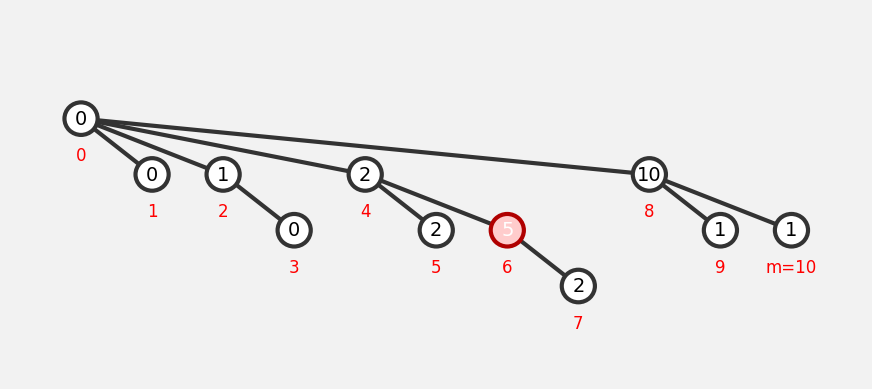

i: 6	 LSOne(6):2	 Next i,(6-LSOne(6)):4	 current sum ft[i]:0	 To Add:5	 New Sum:5


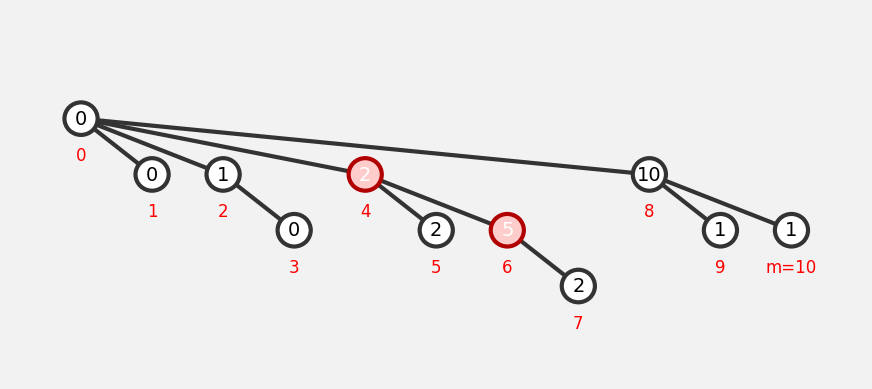

i: 4	 LSOne(4):4	 Next i,(4-LSOne(4)):0	 current sum ft[i]:5	 To Add:2	 New Sum:7


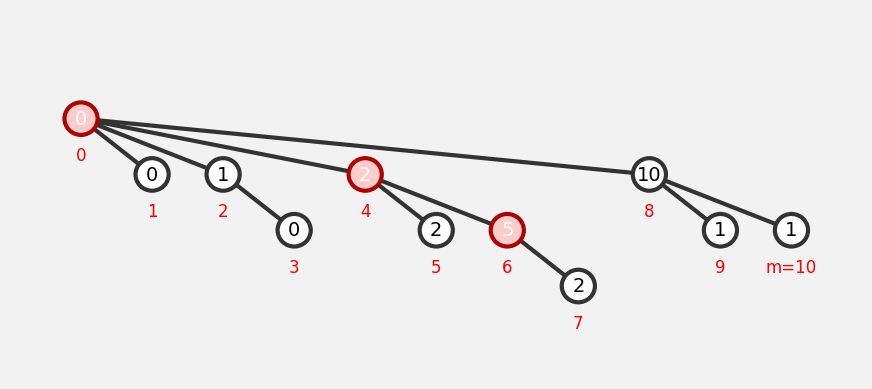

DONE!
------------------------------


7

In [117]:
FT.rsq(6)

i: 5	 LSOne(5):1	 Next i,(5+LSOne(5)):6	 Current Value:2	 ToAdd:2	 New Value:4


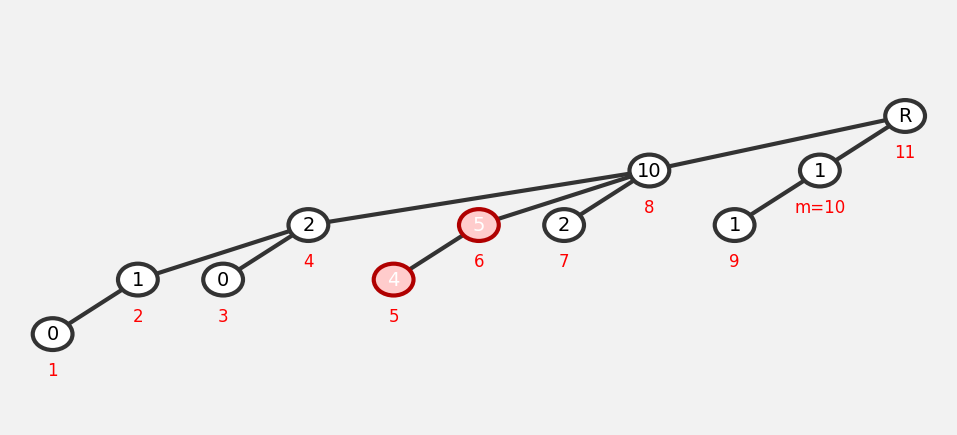

i: 6	 LSOne(6):2	 Next i,(6+LSOne(6)):8	 Current Value:5	 ToAdd:2	 New Value:7


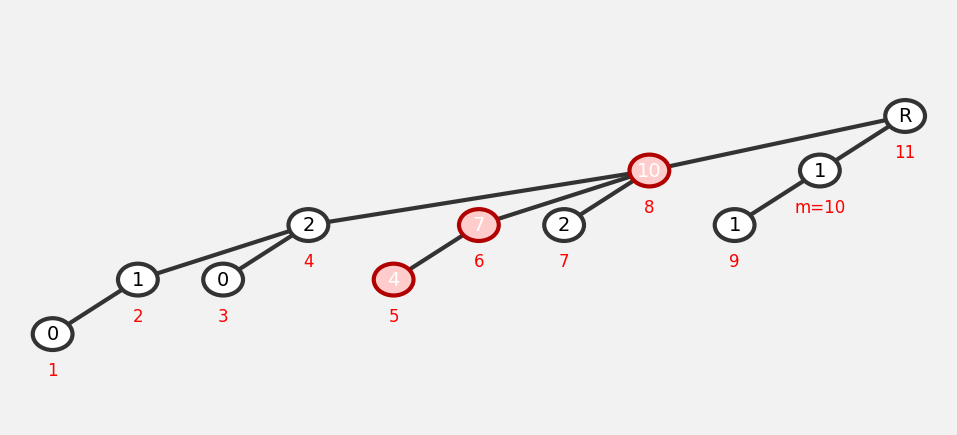

i: 8	 LSOne(8):8	 Next i,(8+LSOne(8)):16	 Current Value:10	 ToAdd:2	 New Value:12


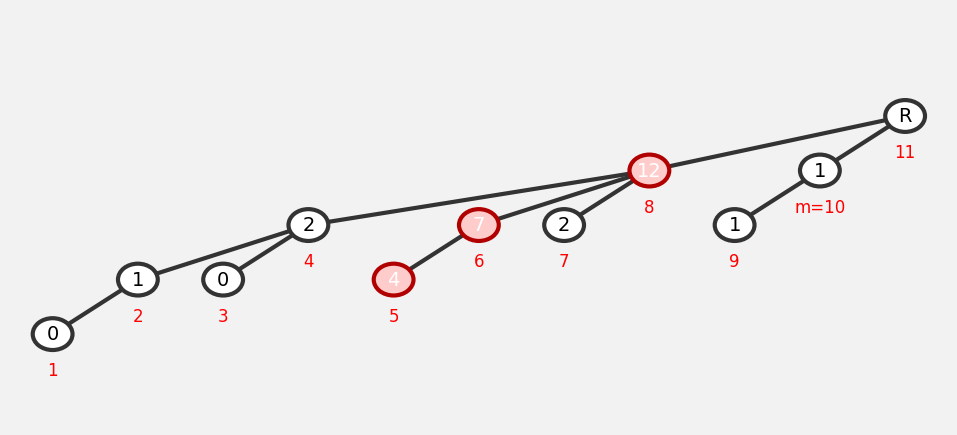

In [126]:
FT.update(5, 2)

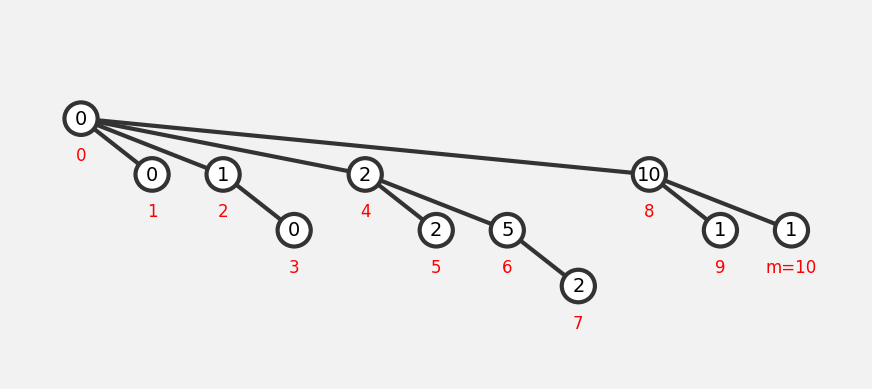

In [105]:
draw_fenwick_tree(FT.ft, one_indexed=True, filename=None)